# Spike v3 — LoRA + IP-Adapter Plus Integration

**Research question:** Does pairing the trained packaging-domain LoRA with IP-Adapter Plus produce snack-packets with regional folk-art style, where Plus alone produced stylised paintings?

**Method:**
- Fixed prompt (p1 from spike v2 — strongest packaging anchor wording)
- 3 traditions (Madhubani, Tanjore, Kalighat)
- 2 seeds (42, 1337)
- 2 conditions: **LoRA off** (Plus only — replicates spike v2 baseline) vs **LoRA on** (combined pipeline — the test)
- IP-Adapter scale fixed at 0.7 (best operating point from spike v2)
- LoRA scale 1.0

**Total images:** 12. Expected runtime on RTX 3060 Laptop: ~25–35 minutes.

**Output:** `outputs/spike/v3_lora_plus/` with a 6-row × 2-column comparison grid (LoRA-off | LoRA-on).

## Cell 1 — Configuration and references

In [1]:
import os, json, time, gc
from pathlib import Path

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"

import torch
from diffusers import AutoPipelineForText2Image
from diffusers.utils import load_image
from transformers import CLIPVisionModelWithProjection
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"
RESOLUTION = 768       # drop to 640 if OOM
STEPS = 25
GUIDANCE = 7.5
IP_SCALE = 0.7
LORA_SCALE = 1.0

TRIGGER = "ipsnackpkg"

# Two prompt versions — same intent, but the LoRA-on version includes the trigger token.
# This is the standard pattern: trigger-conditioned prompts when LoRA is loaded.
PROMPT_BASE = "Front-facing product photograph of an Indian snack packet, professional product photography, white background, sharp focus"
PROMPT_LORA = f"a photograph of {TRIGGER}, Front-facing product photograph of an Indian snack packet, professional product photography, white background, sharp focus"

NEGATIVE = "blurry, low quality, watermark, distorted, deformed, jpeg artifacts, multiple products, framed painting, art print, poster"

REFERENCES = {
    "madhubani": "data/processed/style_references/bihar/Craft-2-from-Sunaina-Thakur.png",
    "tanjore":   "data/processed/style_references/tamil_nadu/Navaneeta_Krishna_-_Google_Art_Project.png",
    "kalighat":  "data/processed/style_references/west_bengal/A_Bengali_Lady_Krishna_Killing_the_Demon_Bakasura_6125147052.png",
}

# Find the LoRA file — update if your filename differs
LORA_DIR = Path("../outputs/lora_checkpoints")
lora_candidates = sorted(LORA_DIR.glob("sdxl_packaging_lora_*.safetensors"))
if not lora_candidates:
    raise FileNotFoundError(f"No LoRA .safetensors found in {LORA_DIR.resolve()}. Download from Drive first.")
LORA_PATH = lora_candidates[-1]   # use the most recent one
print(f"LoRA selected: {LORA_PATH.name}")
print(f"  size: {LORA_PATH.stat().st_size / 1e6:.1f} MB")

SEEDS = [42, 1337]
OUT_DIR = Path("../outputs/spike/v3_lora_plus")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reference sanity check (paths may have been relative — fix if so)
for name, path in list(REFERENCES.items()):
    p = Path(path)
    if not p.exists():
        alt = Path("..") / p
        if alt.exists():
            REFERENCES[name] = str(alt)
        else:
            raise FileNotFoundError(f"Reference for '{name}' not found.")
print("References OK.")

print(f"\nGPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
print(f"Output: {OUT_DIR.resolve()}")

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


LoRA selected: sdxl_packaging_lora_r16_lr0.0001_steps2000_20260603_2249.safetensors
  size: 46.6 MB
References OK.

GPU: NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB)
Output: C:\Users\Vivek\Documents\dissertation\outputs\spike\v3_lora_plus


## Cell 2 — Build pipeline (Plus + LoRA loadable on demand)

Load SDXL with IP-Adapter-Plus once. The LoRA will be loaded and unloaded between the two conditions, so we don't need two pipelines.

In [2]:
print("Loading ViT-H image encoder for IP-Adapter Plus...")
t0 = time.time()
image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    "h94/IP-Adapter",
    subfolder="models/image_encoder",
    torch_dtype=torch.float16,
)
print(f"  {time.time()-t0:.1f}s")

print("\nLoading SDXL...")
t0 = time.time()
pipe = AutoPipelineForText2Image.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
    image_encoder=image_encoder,
)
pipe.enable_model_cpu_offload()
pipe.enable_vae_slicing()
pipe.enable_vae_tiling()
print(f"  SDXL loaded in {time.time()-t0:.1f}s")

print("\nLoading IP-Adapter Plus...")
t0 = time.time()
pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter-plus_sdxl_vit-h.safetensors",
)
if hasattr(pipe, "image_encoder") and pipe.image_encoder is not None:
    pipe.image_encoder.to("cuda")
print(f"  IP-Adapter Plus loaded in {time.time()-t0:.1f}s")

print("\nPipeline ready for both LoRA-on and LoRA-off conditions.")

Loading ViT-H image encoder for IP-Adapter Plus...


Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

  2.4s

Loading SDXL...


C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2294: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


  SDXL loaded in 1.6s

Loading IP-Adapter Plus...
  IP-Adapter Plus loaded in 2.4s

Pipeline ready for both LoRA-on and LoRA-off conditions.


## Cell 3 — Generation loop

In [3]:
def generate(prompt, ref_path, seed, condition_tag, lora_active):
    """One generation with full config logging."""
    out_name = f"{condition_tag}.png"
    out_path = OUT_DIR / out_name
    if out_path.exists():
        return None
    
    pipe.set_ip_adapter_scale(IP_SCALE)
    ref = load_image(ref_path)
    
    # When LoRA is loaded, pass its scale via cross_attention_kwargs
    cross_attn = {"scale": LORA_SCALE} if lora_active else {}
    
    g = torch.Generator(device="cuda").manual_seed(seed)
    t0 = time.time()
    img = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE,
        ip_adapter_image=ref,
        width=RESOLUTION, height=RESOLUTION,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=g,
        cross_attention_kwargs=cross_attn,
    ).images[0]
    elapsed = time.time() - t0
    
    img.save(out_path, "PNG")
    config = {
        "prompt": prompt, "negative_prompt": NEGATIVE,
        "seed": seed, "ip_adapter_scale": IP_SCALE,
        "lora_active": lora_active,
        "lora_scale": LORA_SCALE if lora_active else None,
        "lora_path": str(LORA_PATH) if lora_active else None,
        "reference": str(ref_path),
        "width": RESOLUTION, "height": RESOLUTION,
        "steps": STEPS, "guidance": GUIDANCE,
        "model": MODEL_ID,
        "elapsed_s": round(elapsed, 1),
    }
    out_path.with_suffix(".json").write_text(json.dumps(config, indent=2))
    return elapsed


grand_start = time.time()

# ---- Phase 1: LoRA off (Plus only baseline — replicates spike v2 condition) ----
print("=== Phase 1: LoRA OFF (Plus only) ===")
phase_start = time.time()
for tradition, ref_path in REFERENCES.items():
    for seed in SEEDS:
        tag = f"plus_only_{tradition}_s{seed}"
        print(f"  {tag} ...", end=" ", flush=True)
        elapsed = generate(PROMPT_BASE, ref_path, seed, tag, lora_active=False)
        print("SKIP" if elapsed is None else f"{elapsed:.1f}s")
print(f"Phase 1: {(time.time()-phase_start)/60:.1f} min\n")

# ---- Phase 2: LoRA on ----
print("=== Phase 2: LoRA ON (combined pipeline) ===")
print(f"  Loading LoRA: {LORA_PATH.name}")
pipe.load_lora_weights(str(LORA_PATH))
print("  LoRA loaded.")

phase_start = time.time()
for tradition, ref_path in REFERENCES.items():
    for seed in SEEDS:
        tag = f"lora_plus_{tradition}_s{seed}"
        print(f"  {tag} ...", end=" ", flush=True)
        elapsed = generate(PROMPT_LORA, ref_path, seed, tag, lora_active=True)
        print("SKIP" if elapsed is None else f"{elapsed:.1f}s")
print(f"Phase 2: {(time.time()-phase_start)/60:.1f} min\n")

print(f"TOTAL: {(time.time()-grand_start)/60:.1f} min")
print(f"Outputs: {OUT_DIR.resolve()}")

=== Phase 1: LoRA OFF (Plus only) ===
  plus_only_madhubani_s42 ... 

  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


511.1s
  plus_only_madhubani_s1337 ... 

  0%|          | 0/25 [00:00<?, ?it/s]

...

456.6s
  lora_plus_kalighat_s42 ... 

  0%|          | 0/25 [00:00<?, ?it/s]

454.7s
  lora_plus_kalighat_s1337 ... 

  0%|          | 0/25 [00:00<?, ?it/s]

465.3s
Phase 2: 45.9 min

TOTAL: 90.7 min
Outputs: C:\Users\Vivek\Documents\dissertation\outputs\spike\v3_lora_plus


## Cell 4 — Side-by-side comparison grid

Rows: tradition × seed. Two columns: LoRA-off | LoRA-on. Same reference image and seed in each row, so any difference is *only* due to the LoRA.

Comparison grid: C:\Users\Vivek\Documents\dissertation\outputs\spike\v3_lora_vs_plus_only.png


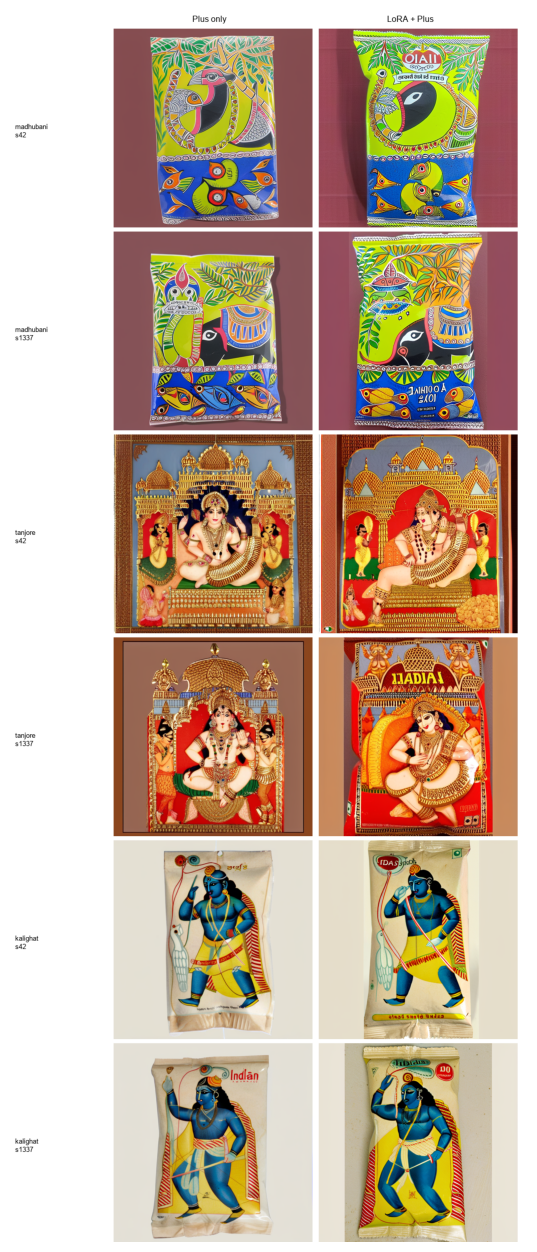

In [4]:
thumb = 384
label_w = 200
col_gap = 12
header_h = 36

rows = []
for tradition in REFERENCES.keys():
    for seed in SEEDS:
        plus_path = OUT_DIR / f"plus_only_{tradition}_s{seed}.png"
        lora_path = OUT_DIR / f"lora_plus_{tradition}_s{seed}.png"
        plus_img = Image.open(plus_path).resize((thumb, thumb)) if plus_path.exists() else None
        lora_img = Image.open(lora_path).resize((thumb, thumb)) if lora_path.exists() else None
        rows.append({"label": f"{tradition}\ns{seed}", "plus": plus_img, "lora": lora_img})

n_rows = len(rows)
canvas_w = label_w + thumb + col_gap + thumb + 20
canvas_h = header_h + n_rows * thumb + (n_rows - 1) * 8
canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
draw = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype("arial.ttf", 16)
    font_small = ImageFont.truetype("arial.ttf", 13)
except Exception:
    font = font_small = ImageFont.load_default()

draw.text((label_w + thumb // 2 - 40, 8), "Plus only", fill="black", font=font)
draw.text((label_w + thumb + col_gap + thumb // 2 - 60, 8), "LoRA + Plus", fill="black", font=font)

y = header_h
for r in rows:
    draw.text((10, y + thumb // 2 - 10), r["label"], fill="black", font=font_small)
    if r["plus"] is not None:
        canvas.paste(r["plus"], (label_w, y))
    if r["lora"] is not None:
        canvas.paste(r["lora"], (label_w + thumb + col_gap, y))
    y += thumb + 8

grid_path = OUT_DIR.parent / "v3_lora_vs_plus_only.png"
canvas.save(grid_path)
print(f"Comparison grid: {grid_path.resolve()}")

plt.figure(figsize=(12, 16))
plt.imshow(canvas); plt.axis("off"); plt.show()

## Cell 5 — Failure-log CSV scaffold

Same rubric as the spike v2 scoring. You'll fill this in over two sessions ≥48h apart.

In [5]:
import pandas as pd

rows = []
for p in sorted(OUT_DIR.glob("*.png")):
    stem = p.stem
    condition = "plus_only" if stem.startswith("plus_only_") else "lora_plus"
    parts = stem.split("_")
    # tradition + seed are last two meaningful tokens
    tradition = parts[-2]
    seed = parts[-1].lstrip("s")
    rows.append({
        "filename": p.name,
        "condition": condition,
        "tradition": tradition,
        "seed": seed,
        "session1_text_legibility": "",
        "session1_regional_appropriateness": "",
        "session1_packaging_plausibility": "",
        "session1_visual_quality": "",
        "session1_date": "",
        "session2_text_legibility": "",
        "session2_regional_appropriateness": "",
        "session2_packaging_plausibility": "",
        "session2_visual_quality": "",
        "session2_date": "",
        "failure_mode": "",
        "notes": "",
    })

df = pd.DataFrame(rows)
log_path = Path("../evaluation/spike_v3_scores.csv")
log_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(log_path, index=False)
print(f"Score scaffold: {log_path.resolve()}  ({len(df)} rows)")

Score scaffold: C:\Users\Vivek\Documents\dissertation\evaluation\spike_v3_scores.csv  (12 rows)


## What to look for in the comparison grid

Open `outputs/spike/v3_lora_vs_plus_only.png` and ask, row by row:

**Plus-only column (left):** Does it look like the spike v2 Plus outputs — packets with regional art applied? It should, because this is the same condition. If it looks identical to your spike v2 outputs at scale=0.7, the pipeline is consistent.

**LoRA+Plus column (right):** This is the question. Three possible patterns:

1. **LoRA helps** — packets look more *commercially packet-like* (visible brand zones, layout, product photography conventions) while still carrying the regional style. **Best outcome.** Architecture validated.

2. **LoRA dominates** — outputs look like generic Indian snack packets with the regional style suppressed or washed out. LoRA is overpowering Plus. **Action:** lower `LORA_SCALE` to 0.5 or 0.7 and re-run.

3. **No visible difference** — left and right look essentially the same. LoRA isn't asserting through Plus's signal. **Action:** retrain LoRA with higher rank or longer training (the option we deferred earlier).

Kalighat is the canary tradition. Plus alone failed for Kalighat (no style transfer). If LoRA+Plus still produces no Kalighat style, that's the broader limit we already identified, not a LoRA failure.